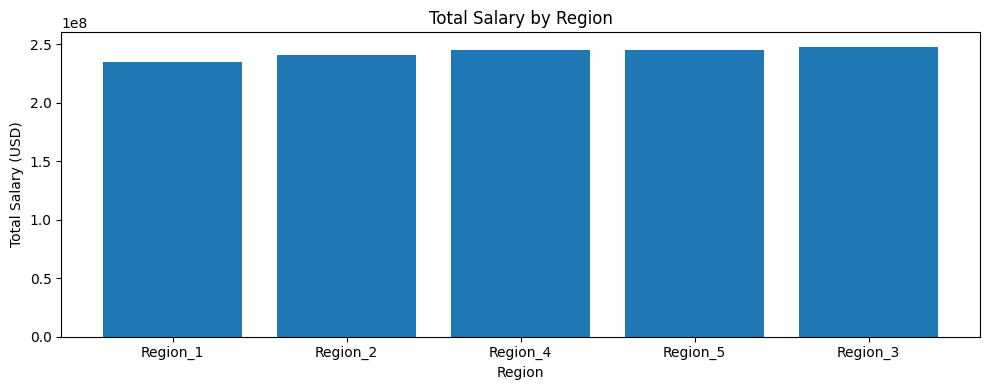

In [1]:
# Hierarchical Big Data Visualizations (Matplotlib-only)
# Dataset: hierarchical_bigdata_org.csv
# Notes: One chart per figure, no seaborn, no custom colors/styles.

# --------------------------------------------------------------------------------
# 1) Total salary by region (bar)
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")
by_region = df.groupby("region")["salary_usd"].sum().sort_values()

plt.figure(figsize=(10,4))
plt.bar(by_region.index, by_region.values)
plt.title("Total Salary by Region")
plt.xlabel("Region"); plt.ylabel("Total Salary (USD)")
plt.tight_layout(); plt.show()

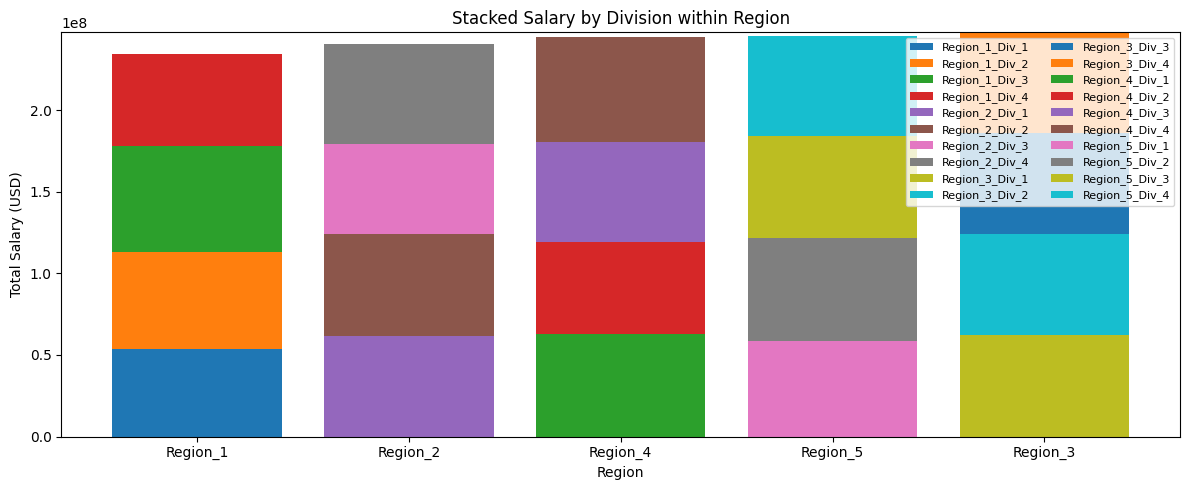

In [3]:
# --------------------------------------------------------------------------------
# 2) Stacked bar: divisions within regions (total salary)
# --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")

pvt = (
    df.pivot_table(index="region", columns="division", values="salary_usd", aggfunc="sum")
      .fillna(0)
)
pvt = pvt.loc[pvt.sum(axis=1).sort_values().index]

plt.figure(figsize=(12,5))

bottom = np.zeros(len(pvt))
for col in pvt.columns:
    plt.bar(pvt.index, pvt[col].values, bottom=bottom, label=col)
    bottom += pvt[col].values

plt.title("Stacked Salary by Division within Region")
plt.xlabel("Region")
plt.ylabel("Total Salary (USD)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

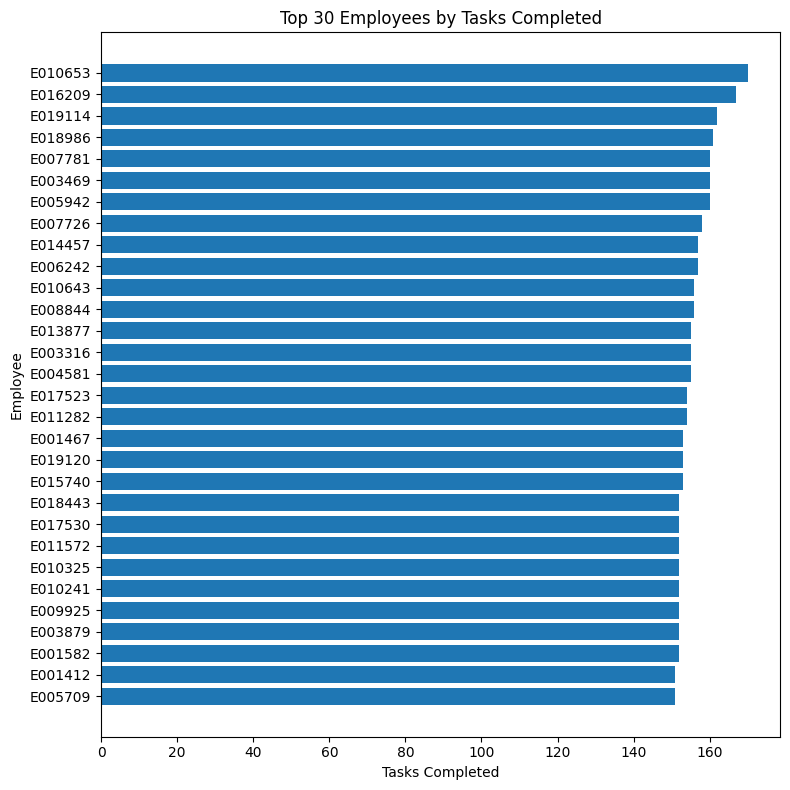

In [4]:
# --------------------------------------------------------------------------------
# 3) Top-30 employees by tasks (horizontal bar)
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")
top = df.nlargest(30, "tasks_completed")[["employee_id", "tasks_completed"]].sort_values("tasks_completed")

plt.figure(figsize=(8,8))
plt.barh(top["employee_id"], top["tasks_completed"])
plt.title("Top 30 Employees by Tasks Completed")
plt.xlabel("Tasks Completed"); plt.ylabel("Employee")
plt.tight_layout(); plt.show()

C:\Users\sakib\AppData\Local\Temp\ipykernel_11772\3845259148.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


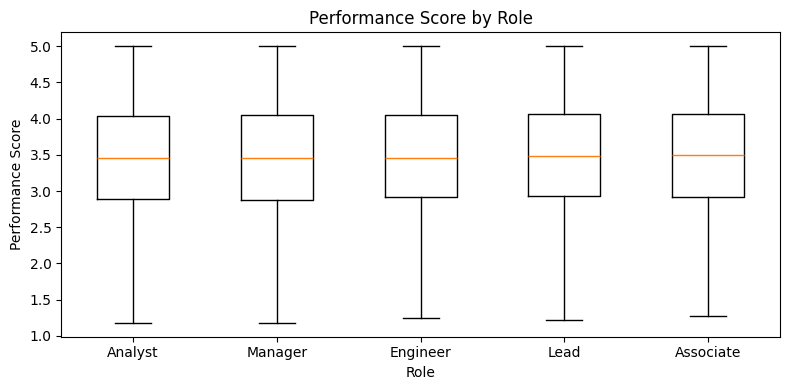

In [5]:
# --------------------------------------------------------------------------------
# 4) Boxplot of performance by role
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")
order = df.groupby("role")["performance_score"].median().sort_values().index
data = [df[df["role"]==r]["performance_score"].values for r in order]

plt.figure(figsize=(8,4))
plt.boxplot(data, labels=order, showfliers=False)
plt.title("Performance Score by Role")
plt.xlabel("Role"); plt.ylabel("Performance Score")
plt.tight_layout(); plt.show()

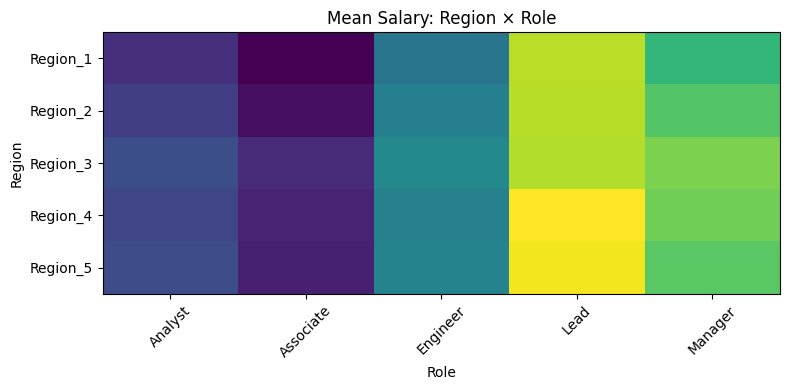

In [6]:
# --------------------------------------------------------------------------------
# 5) Heatmap (imshow): mean salary by region × role
# --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")
pvt = df.pivot_table(index="region", columns="role", values="salary_usd", aggfunc="mean")
arr = pvt.values

plt.figure(figsize=(8,4))
plt.imshow(arr, aspect="auto", origin="upper")
plt.title("Mean Salary: Region × Role")
plt.xlabel("Role"); plt.ylabel("Region")
plt.xticks(range(len(pvt.columns)), pvt.columns, rotation=45)
plt.yticks(range(len(pvt.index)), pvt.index)
plt.tight_layout(); plt.show()


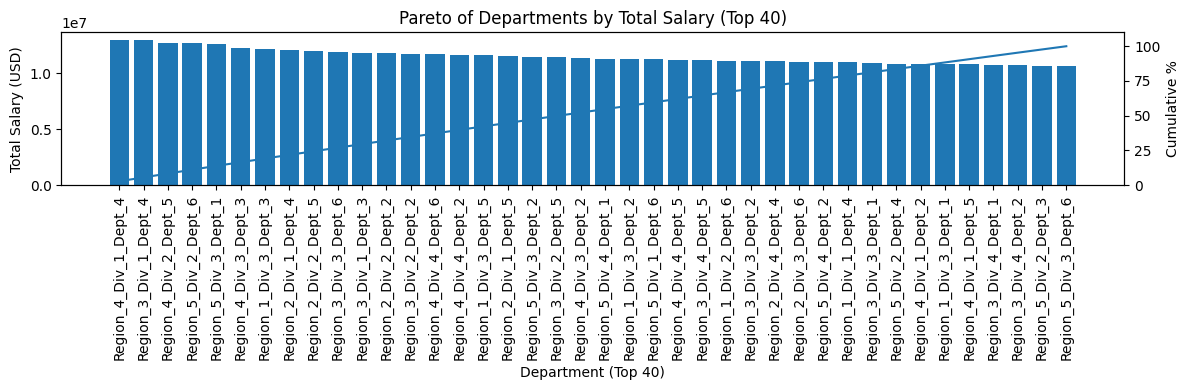

In [7]:
# --------------------------------------------------------------------------------
# 6) Pareto chart: departments (salary share, cumulative %)
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("hierarchical_bigdata_org.csv")
dep = df.groupby("department")["salary_usd"].sum().sort_values(ascending=False).head(40)

cum = dep.cumsum()/dep.sum()*100
x = range(len(dep))

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.bar(x, dep.values)
ax1.set_xlabel("Department (Top 40)")
ax1.set_ylabel("Total Salary (USD)")
ax1.set_xticks(x); ax1.set_xticklabels(dep.index, rotation=90)

ax2 = ax1.twinx()
ax2.plot(x, cum.values)
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 110)

plt.title("Pareto of Departments by Total Salary (Top 40)")
plt.tight_layout(); plt.show()

C:\Users\sakib\AppData\Local\Temp\ipykernel_11772\1953773721.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


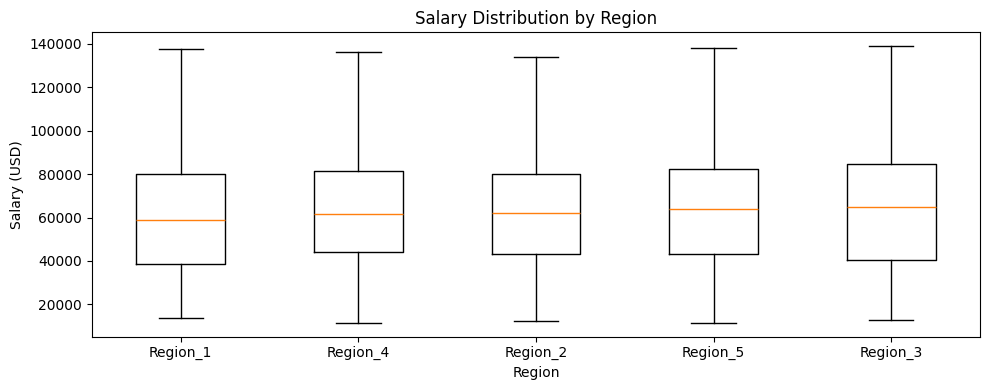

In [8]:
# --------------------------------------------------------------------------------
# 7) Salary distribution by region (boxplot)
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")
order = df.groupby("region")["salary_usd"].median().sort_values().index
data = [df[df["region"]==r]["salary_usd"].values for r in order]

plt.figure(figsize=(10,4))
plt.boxplot(data, labels=order, showfliers=False)
plt.title("Salary Distribution by Region")
plt.xlabel("Region"); plt.ylabel("Salary (USD)")
plt.tight_layout(); plt.show()

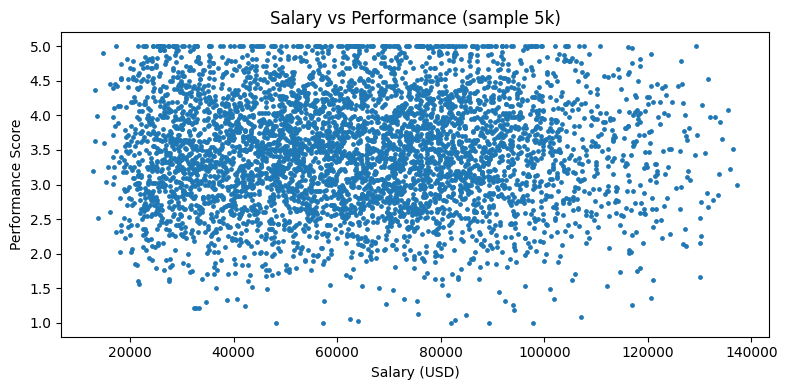

In [9]:
# --------------------------------------------------------------------------------
# 8) Scatter: salary vs performance (sample 5k)
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv").sample(5000, random_state=0)

plt.figure(figsize=(8,4))
plt.scatter(df["salary_usd"], df["performance_score"], s=6)
plt.title("Salary vs Performance (sample 5k)")
plt.xlabel("Salary (USD)"); plt.ylabel("Performance Score")
plt.tight_layout(); plt.show()

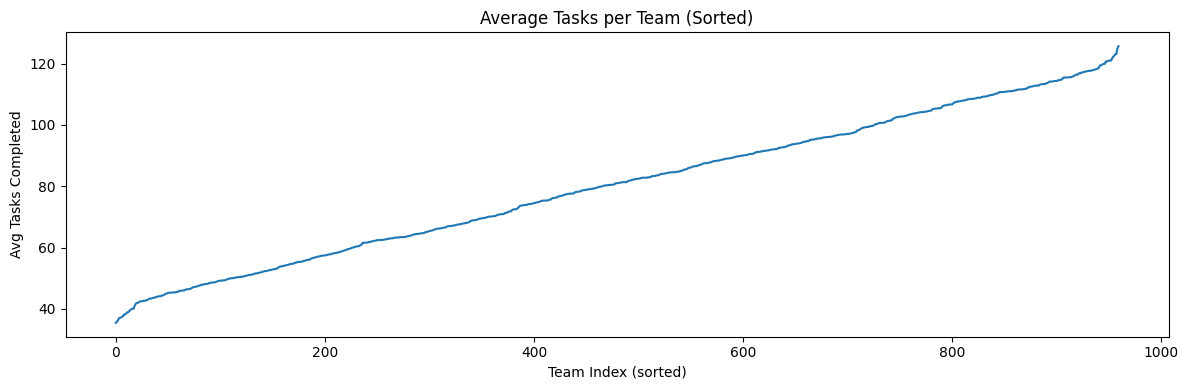

In [10]:
# --------------------------------------------------------------------------------
# 9) Aggregation line: average tasks per team (sorted)
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("hierarchical_bigdata_org.csv")
by_team = df.groupby("team")["tasks_completed"].mean().sort_values()

plt.figure(figsize=(12,4))
plt.plot(range(len(by_team)), by_team.values)
plt.title("Average Tasks per Team (Sorted)")
plt.xlabel("Team Index (sorted)"); plt.ylabel("Avg Tasks Completed")
plt.tight_layout(); plt.show()


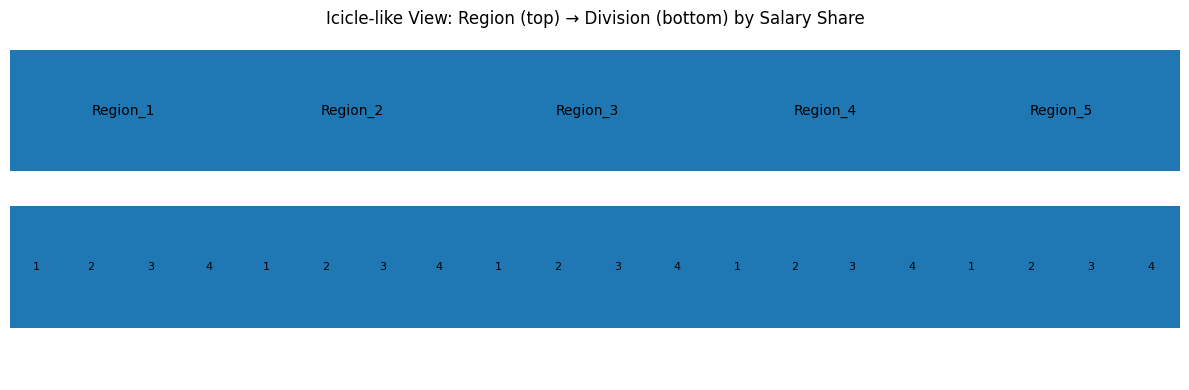

In [11]:
# --------------------------------------------------------------------------------
# 10) Icicle-like rectangles: Region (top) → Division (bottom) by salary share
# --------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("hierarchical_bigdata_org.csv")

reg = df.groupby("region")["salary_usd"].sum()
reg = reg / reg.sum()

div = df.groupby(["region", "division"])["salary_usd"].sum()
div = div / div.groupby(level=0).transform("sum")

plt.figure(figsize=(12,4))

x0 = 0.0
for r, w in reg.items():
    plt.gca().add_patch(plt.Rectangle((x0, 0.6), w, 0.35))
    plt.text(x0 + w/2, 0.775, r, ha="center", va="center")
    x1 = x0
    sub = div.loc[r]
    for dv, w2 in sub.items():
        width = w * w2
        plt.gca().add_patch(plt.Rectangle((x1, 0.15), width, 0.35))
        if width > 0.02:
            plt.text(x1 + width/2, 0.325, dv.split("_Div_")[-1], ha="center", va="center", fontsize=8)
        x1 += width
    x0 += w

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis("off")
plt.title("Icicle-like View: Region (top) → Division (bottom) by Salary Share")
plt.tight_layout(); plt.show()